In [85]:
# import des bibliothèques nécessaires
import numpy as np
from datetime import datetime
import pandas as pd
from sklearn.pipeline import Pipeline # ok
from sklearn.compose import ColumnTransformer #ok
from sklearn.impute import SimpleImputer #, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso #LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score # KFold
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go
import plotly.io as pio
# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg" # to be replaced by "iframe" if working on JULIE

In [86]:
dataset = pd.read_csv('Walmart_Store_sales.csv') # chargement base de données
dataset.head()
dataset.shape[0]
dataset.info() # info sur les valeurs non-nulles de chaque colonne et type de données
dataset.describe(include="all") # statistiques résumées

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         150 non-null    float64
 1   Date          132 non-null    object 
 2   Weekly_Sales  136 non-null    float64
 3   Holiday_Flag  138 non-null    float64
 4   Temperature   132 non-null    float64
 5   Fuel_Price    136 non-null    float64
 6   CPI           138 non-null    float64
 7   Unemployment  135 non-null    float64
dtypes: float64(7), object(1)
memory usage: 9.5+ KB


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,150.000000,132,1.360000e+02,138.000000,132.000000,136.000000,138.000000,135.000000
unique,NaN,85,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,19-10-2012,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN
mean,9.866667,NaN,1.249536e+06,0.079710,61.398106,3.320853,179.898509,7.598430
std,6.231191,NaN,6.474630e+05,0.271831,18.378901,0.478149,40.274956,1.577173
min,1.000000,NaN,2.689290e+05,0.000000,18.790000,2.514000,126.111903,5.143000
25%,4.000000,NaN,6.050757e+05,0.000000,45.587500,2.852250,131.970831,6.597500
50%,9.000000,NaN,1.261424e+06,0.000000,62.985000,3.451000,197.908893,7.470000
75%,15.750000,NaN,1.806386e+06,0.000000,76.345000,3.706250,214.934616,8.150000


In [87]:
# Conversion des dates du format objet au format date
dataset["Date"] = pd.to_datetime(dataset['Date'], format='%d-%m-%Y')

In [88]:
print(f"Période couverte du ", dataset["Date"].min(), "au", dataset["Date"].max())

Période couverte du  2010-02-05 00:00:00 au 2012-10-19 00:00:00


In [89]:
# Conversion des températures de degrés Fahrenheit en degrés Celsius
dataset['Temperature']=(dataset['Temperature']-32 )/ 1.8

In [90]:
# Pourcentage de valeurs manquantes
display(100 * dataset.isnull().sum() / dataset.shape[0])

Store            0.000000
Date            12.000000
Weekly_Sales     9.333333
Holiday_Flag     8.000000
Temperature     12.000000
Fuel_Price       9.333333
CPI              8.000000
Unemployment    10.000000
dtype: float64

In [91]:
# Suppression valeurs manquantes dans Weekly_Sales
df = dataset.dropna(subset=['Weekly_Sales'])

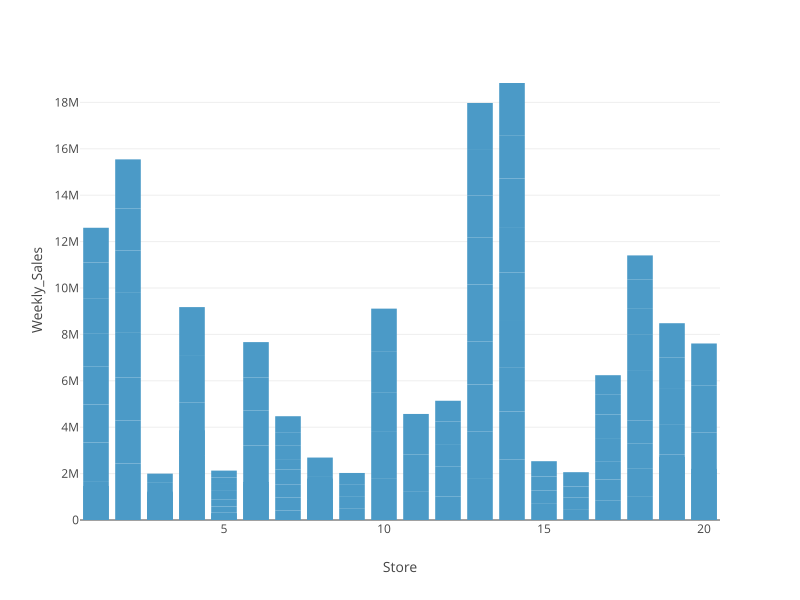

In [92]:
# Visualisation des ventes par magasin 
def display_bar(f):
    fig = px.bar(dataset, x= f, y = "Weekly_Sales", height=600, width=800)
    fig.show()

display_bar('Store')

In [93]:
# Présentation de BoxPlot pour visualiser la répartition des valeurs dans les différentes colonnes.

<Axes: ylabel='Temperature'>

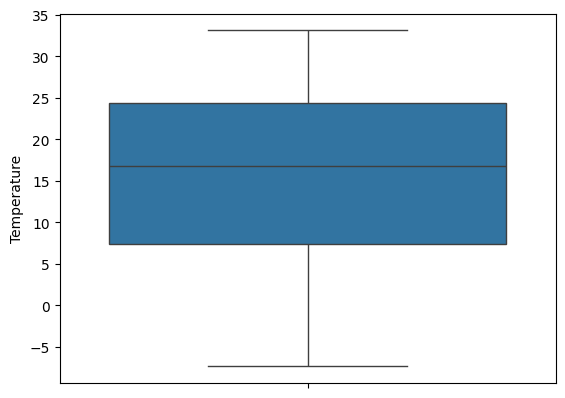

In [94]:
sns.boxplot(df['Temperature'])

<Axes: ylabel='Fuel_Price'>

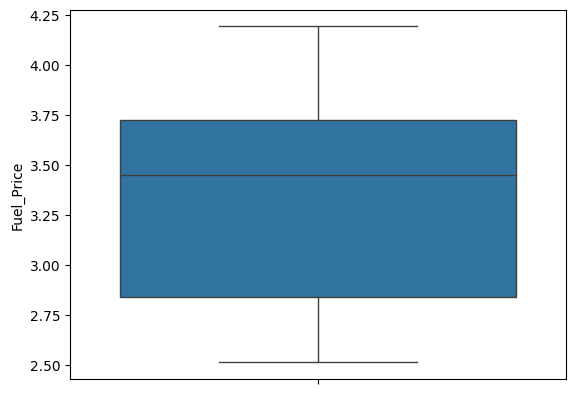

In [95]:
sns.boxplot(df['Fuel_Price'])

<Axes: ylabel='CPI'>

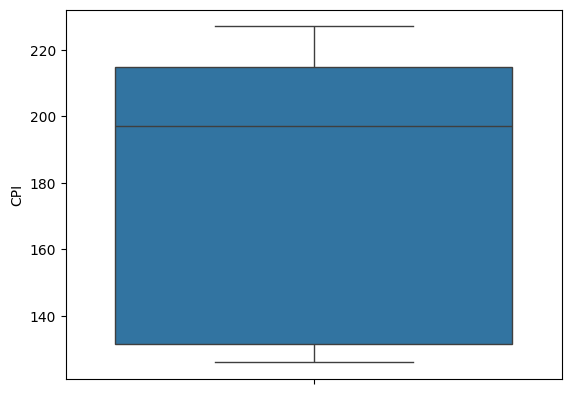

In [96]:
sns.boxplot(df['CPI'])

<Axes: ylabel='Unemployment'>

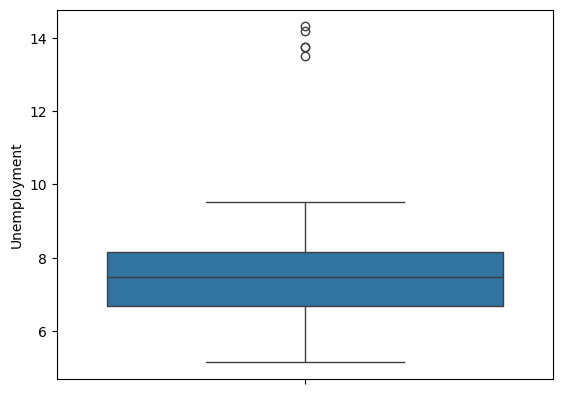

In [97]:
sns.boxplot(df['Unemployment'])

In [98]:
# On constate la présence de "outliers"
# suppression des valeurs plus éloignées que 3 écart-types
q1u = df['Unemployment'].quantile(0.25)
q3u = df['Unemployment'].quantile(0.75)
iqru = q3u - q1u

unempmin = q1u - 1.5*iqru
unempmax = q3u + 1.5*iqru

df = df[(df['Unemployment'] >= unempmin) & (df['Unemployment'] <=unempmax)]
print(df.head())


   Store       Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0    6.0 2011-02-18    1572117.54           NaN    15.338889       3.045   
1   13.0 2011-03-25    1807545.43           0.0     5.766667       3.435   
3   11.0        NaT    1244390.03           0.0    29.205556         NaN   
4    6.0 2010-05-28    1644470.66           0.0    26.050000       2.759   
5    4.0 2010-05-28    1857533.70           0.0          NaN       2.756   

          CPI  Unemployment  
0  214.777523         6.858  
1  128.616064         7.470  
3  214.556497         7.346  
4  212.412888         7.092  
5  126.160226         7.896  


<Axes: ylabel='Unemployment'>

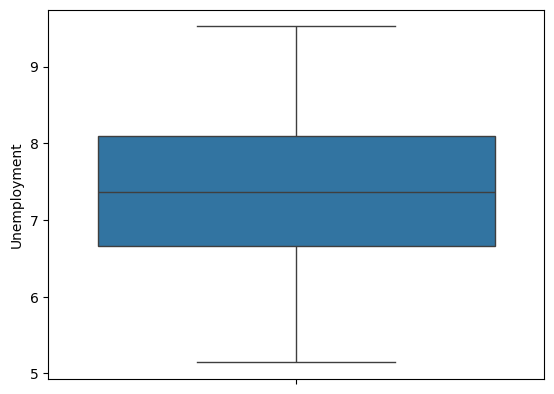

In [99]:
# Vérification qu'il n'y a plus de valeur extrême dans la colonne "Unemployment"
sns.boxplot(df['Unemployment'])

In [100]:
# décomposition de la colonne "date" par élément
df=df.dropna(subset=['Date'])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.weekday

In [101]:
# détection quels jours de la semaine
print(df['Weekday'].min())
print(df['Weekday'].max())

4
4


In [102]:
# comme c'est toujours le même jour de la semaine, on peut supprimer cette colonne avec la colonne 'Date' car elle ne donne pas d'information intéressante
useless_cols = ["Date", "Weekday"]
df = df.drop(useless_cols, axis=1)

In [103]:
# Visualisation de la base après correction
df.head()


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day
0,6.0,1572117.54,NaN,15.338889,3.045,214.777523,6.858,2011,2,18
1,13.0,1807545.43,0.0,5.766667,3.435,128.616064,7.470,2011,3,25
4,6.0,1644470.66,0.0,26.050000,2.759,212.412888,7.092,2010,5,28
5,4.0,1857533.70,0.0,NaN,2.756,126.160226,7.896,2010,5,28
6,15.0,695396.19,0.0,21.000000,4.069,134.855161,7.658,2011,6,3


In [104]:
# Nombre de valeurs nulles par colonne
df.isnull().sum()

Store            0
Weekly_Sales     0
Holiday_Flag     9
Temperature      8
Fuel_Price      10
CPI              8
Unemployment     0
Year             0
Month            0
Day              0
dtype: int64

In [105]:
# remplacement valeurs manquantes par moyennes, et pour les indicateurs de vacances, remplacer par 0 
df = df.fillna({'Holiday_Flag': 0,'Temperature' : df['Temperature'].mean(), 'Fuel_Price' : df['Fuel_Price'].mean(), 'CPI' : df['CPI'].mean()} )

In [106]:
# vérification qu'il n'y a plus de valeurs manquantes
df.isnull().sum()

Store           0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Year            0
Month           0
Day             0
dtype: int64

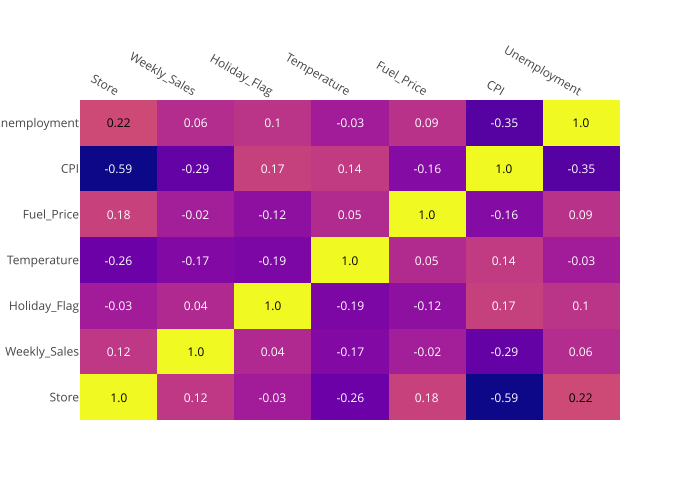

In [107]:
# Matrice de Correlation
corr_matrix = dataset.corr(numeric_only=True).round(2)

fig = ff.create_annotated_heatmap(corr_matrix.values,
                                  x = corr_matrix.columns.tolist(),
                                  y = corr_matrix.index.tolist())


fig.show()
# On constate qu'il n'y a pas de réelle corrélation entre les valeurs et "Weekly_Sales"

In [108]:
# Séparation entre variable cible et variables dépendantes
features_list = ["Store", "Holiday_Flag", "Temperature", "Fuel_Price", "CPI", "Unemployment", "Year", "Month", "Day"]
target_name = "Weekly_Sales"
x = df.loc[:,features_list]
y = df.loc[:,target_name]

In [109]:
print(x.head())
print()
print(y.head())

   Store  Holiday_Flag  Temperature  Fuel_Price         CPI  Unemployment  \
0    6.0           0.0    15.338889       3.045  214.777523         6.858   
1   13.0           0.0     5.766667       3.435  128.616064         7.470   
4    6.0           0.0    26.050000       2.759  212.412888         7.092   
5    4.0           0.0    15.691017       2.756  126.160226         7.896   
6   15.0           0.0    21.000000       4.069  134.855161         7.658   

   Year  Month  Day  
0  2011      2   18  
1  2011      3   25  
4  2010      5   28  
5  2010      5   28  
6  2011      6    3  

0    1572117.54
1    1807545.43
4    1644470.66
5    1857533.70
6     695396.19
Name: Weekly_Sales, dtype: float64


In [110]:
# Tri entre les colonnes numériques et catégorielles
numeric_features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day']
categorical_features = ['Store', 'Holiday_Flag']

In [111]:
# séparation entre 80 % des données pour entrainement et 20 % pour tester le modèle
print("Division des sets entrainement/test...")
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("faite")

Division des sets entrainement/test...
faite


In [112]:
# Création de la pipeline pour les valeurs numériques
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

In [113]:
# Création de la pipeline pour les valeurs catégorielles
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop="first"))# handle_unknown="ignore")) # la première colonne sera supprimée pour éviter la multicolinéarité
    ])

In [114]:
# Utilisation de ColumnTransformer pour effectuer les prétraitements selon catégorie de valeurs
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [115]:
# Preprocessing sur set d'entrainement
print("Réalisation preprocessings sur train set...")
print(x_train.head())
x_train = preprocessor.fit_transform(x_train)
print('...Faite.')
print(x_train[0:15])
print()


Réalisation preprocessings sur train set...
     Store  Holiday_Flag  Temperature  Fuel_Price         CPI  Unemployment  \
67     3.0           0.0     7.616667    2.572000  214.424881         7.368   
28    17.0           0.0     7.344444    2.915000  126.562100         6.635   
98    10.0           0.0    32.400000    3.301587  126.126600         9.524   
55    13.0           0.0    17.555556    3.648000  129.518333         6.877   
143    3.0           0.0    25.850000    2.705000  214.495838         7.343   

     Year  Month  Day  
67   2010      2    5  
28   2010      4   16  
98   2010      6   25  
55   2011      9   23  
143  2010      6    4  
...Faite.
[[-0.90480495 -1.56535563  0.86261319 -0.00373383 -1.02247472 -1.46108171
  -1.48071291  0.          1.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [-0.93315576 -0.81258614 -1

In [116]:
# Preprocessing sur set de test
print("Réalisation preprocessings sur test set...")
print(x_test.head())
x_test = preprocessor.transform(x_test) # on ne réajuste pas le modèle en test pour valider les décisions
# on ne peut qu'appliquer les transformations paramétrées à l'aide de l'ensemble d'entrainement
# sinon on créerait un biais dans les résultats
print('...Faite.')
print(x_test[0:5,:])
print()

Réalisation preprocessings sur test set...
    Store  Holiday_Flag  Temperature  Fuel_Price         CPI  Unemployment  \
39    5.0           0.0    15.950000    3.297000  218.569962         6.300   
96    8.0           0.0     9.866667    3.301587  214.749245         6.299   
85    2.0           0.0     7.050000    2.976000  211.064888         8.028   
59   14.0           0.0     2.694444    3.695000  189.842483         8.424   
53   14.0           0.0     5.422222    3.625000  184.994368         8.549   

    Year  Month  Day  
39  2011     11   11  
96  2010      3   12  
85  2011      1    7  
59  2012      2   17  
53  2011      3   25  
...Faite.
[[-3.69229424e-02  2.57752183e-02  9.72579423e-01 -1.09497168e+00
   1.77821690e-01  1.46509567e+00 -7.39593987e-01  0.00000000e+00
   0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000

In [117]:
# Modèle de régression linéaire sur modèle d'entrainement
print("Régression linéaire sur modèle d'entrainement...")
regressor = LinearRegression()
regressor.fit(x_train, y_train)
print("...Fait.")


Régression linéaire sur modèle d'entrainement...
...Fait.


In [118]:
# Prédiction selon régression linéaire sur le set d'entrainement
print("Prédiction selon régression linéaire sur le set d'entrainement...")
y_train_pred = regressor.predict(x_train)
print("...Faite.")
print(y_train_pred)
print()


Prédiction selon régression linéaire sur le set d'entrainement...
...Faite.
[ 509565.85615378  762891.03948121 1651426.46426117 1970002.89424899
  431941.61087034  223281.01062724  338869.00020924  419974.80081551
 1554344.71799433  132198.8204814  1515872.76020774 1348775.96014418
 2227693.87860702  988102.37940493  496254.83159996 2087798.60129737
 1398790.87230601 2018352.64896103 1878627.19923529 1200221.03351399
 2033261.10212426 1547221.55816492 1185417.14633307 1938597.90302247
 2359869.67880918  303645.81606438  914726.06051879  936800.3110851
 2064498.07643466 1955257.08005436 1974518.75271635 2048776.81111622
  515435.52534606 2021189.22631953 1426071.65444456 1532297.6893723
  504559.68743422 1757242.51        794974.0389149  1563726.16089106
  239213.71751431  570661.84042899 1522668.03974689  427042.50690702
 1354371.65303706  436161.63623273 1996126.63069419 1629171.21135848
  335016.4588433   612101.78992171  476978.56419822  473847.08105586
 2055981.77144053  570611.23 

In [119]:
# Predictions selon régression linéaire sur le set de test
print("Predictions selon régression linéaire sur le set de test...")
y_test_pred = regressor.predict(x_test)
print("...Fait.")
print(y_test_pred)
print()

Predictions selon régression linéaire sur le set de test...
...Fait.
[ 490724.15161664  894240.01660667 1977398.10330643 2144794.77961762
 2063462.47888809 2118185.18070714 1968264.47461268  857603.16770886
  886959.52586108 1604373.83817388 1485660.77529984 1003284.4860403
  420093.96525518  458192.35858966  877888.52211593  586136.18715492
 2083039.16343766  420875.83448815 1990219.87692385 1427046.93912488
 2068584.49203938]



In [120]:
# Affichage des scores R²
print("R2 score sur set d'entrainement : ", r2_score(y_train, y_train_pred))
print("R2 score sur set de test : ", r2_score(y_test, y_test_pred))

R2 score sur set d'entrainement :  0.9746557358565914
R2 score sur set de test :  0.9514784007265408


In [121]:
# Le score R2 semble très bon sur l'entrainement, et tout à fait satisfaisant sur le test.

In [122]:
# Contrôle surapprentissage
scores = cross_val_score(regressor, x_train, y_train, cv=5)
avg = scores.mean()
std = scores.std()
print('Précision validée par croisement : {}\nEcart-type : {}'.format(avg, std))
print("R2 score sur set de test set final : ", regressor.score(x_test, y_test) + std, "or ", regressor.score(x_test, y_test) - std)
print("et c'est inférieur au R2 score sur set d'entrainement :", regressor.score(x_train, y_train)) 

Précision validée par croisement : 0.8887493784527803
Ecart-type : 0.047798299504825295
R2 score sur set de test set final :  0.999276700231366 or  0.9036801012217155
et c'est inférieur au R2 score sur set d'entrainement : 0.9746557358565914


In [123]:
# L'écart type paraît trop faible pour obtenir un score de test dans un intervalle incluant le test d'entraînement.
# On a donc un peu de surapprentissage ici que nous allons essayer de corriger dans la dernière partie.

In [124]:
# Calcul des coefficients mesurant l'importance des différentes valeurs
column_names = preprocessor.get_feature_names_out().tolist()

coefs = pd.DataFrame(index = column_names, data = regressor.coef_.transpose(), columns=["coefficients"])
coefs.index = coefs.index.str.replace(r"^(num__|cat__)", "", regex=True) # To drop the num__ and cat__ in the name of categories
coefs

,coefficients
Temperature,-7.461121e+04
Fuel_Price,-4.868316e+04
CPI,5.305418e+04
Unemployment,-5.218732e+04
Year,2.032024e+04
Month,5.451763e+04
Day,-4.803002e+04
Store_2.0,3.125005e+05
Store_3.0,-1.239216e+06
Store_4.0,5.904694e+05


In [125]:
# Le store 1.0 a été retiré pour éviter la colinéarité, 
# et le store 12.0 n'apparaît pas car les valeurs apparaissant en "Unemployment" étaient au-delà de 3 écarts-types et ont donc été exclues

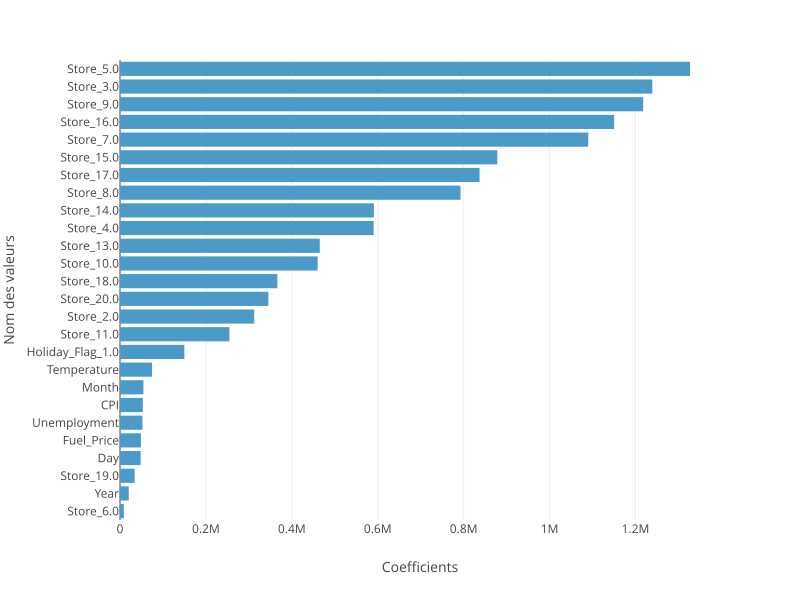

In [126]:
# Calcul des valeurs absolues et tri des valeurs
feature_importance = abs(coefs).sort_values(by = 'coefficients')
# Réalisation d'histogramme montrant les variables explicatives ayant le plus d'impact
fig = px.bar(feature_importance, orientation = 'h')
fig.update_layout(showlegend = False,
                  margin = {'l': 120},
                  height = 600, width = 800,
                  yaxis_title = "Nom des valeurs",
                  xaxis_title = "Coefficients"
                 )
fig.show()

In [127]:
# On constate un impact fort du numéro de Store dans notre modèle à quelques exceptions près.

In [128]:
# Régularisation L2 RIDGE avec 3 essais de paramètres pour éviter surapprentissage
ridge1 = Ridge(alpha = 0.1)
print(ridge1)
ridge1.fit(x_train, y_train)
# Impression R² scores
print("R2 score sur set d'entrainement : ", ridge1.score(x_train, y_train))
print("R2 score sur set de test : ", ridge1.score(x_test, y_test))


Ridge(alpha=0.1)
R2 score sur set d'entrainement :  0.972531227583258
R2 score sur set de test :  0.9601005978741056


In [129]:
ridge2 = Ridge(alpha = 1)
print(ridge2)
ridge2.fit(x_train, y_train)
# Impression R² scores
print("R2 score sur set d'entrainement : ", ridge2.score(x_train, y_train))
print("R2 score sur set de test : ", ridge2.score(x_test, y_test))


Ridge(alpha=1)
R2 score sur set d'entrainement :  0.9224626045483345
R2 score sur set de test :  0.916541705535939


In [130]:
ridge3 = Ridge(alpha = 10)
print(ridge3)
ridge3.fit(x_train, y_train)
# Print R^2 scores
print("R2 score sur set d'entrainement : ", ridge3.score(x_train, y_train))
print("R2 score sur set de test : ", ridge3.score(x_test, y_test))


Ridge(alpha=10)
R2 score sur set d'entrainement :  0.5797997989122491
R2 score sur set de test :  0.4575807652948982


In [131]:
data_dict = {
    'Feature' : preprocessor.get_feature_names_out().tolist(),
    'Ridge1' : ridge1.coef_,
    'Ridge2' : ridge2.coef_,
    'Ridge3' : ridge3.coef_
}

In [132]:
coefficients_ridge = pd.DataFrame(data = data_dict)
coefficients_ridge['Feature'] = coefficients_ridge["Feature"].str.replace(r"^(num__|cat__)", "", regex=True)
coefficients_ridge.head()

,Feature,Ridge1,Ridge2,Ridge3
0,Temperature,-64888.759362,-33307.532997,-23800.677117
1,Fuel_Price,-46086.976188,-27984.186592,-5334.595443
2,CPI,53520.020653,-67623.463633,-193742.313293
3,Unemployment,-3227.472035,77038.555397,62495.352332
4,Year,35200.573671,42400.633279,-14232.225319


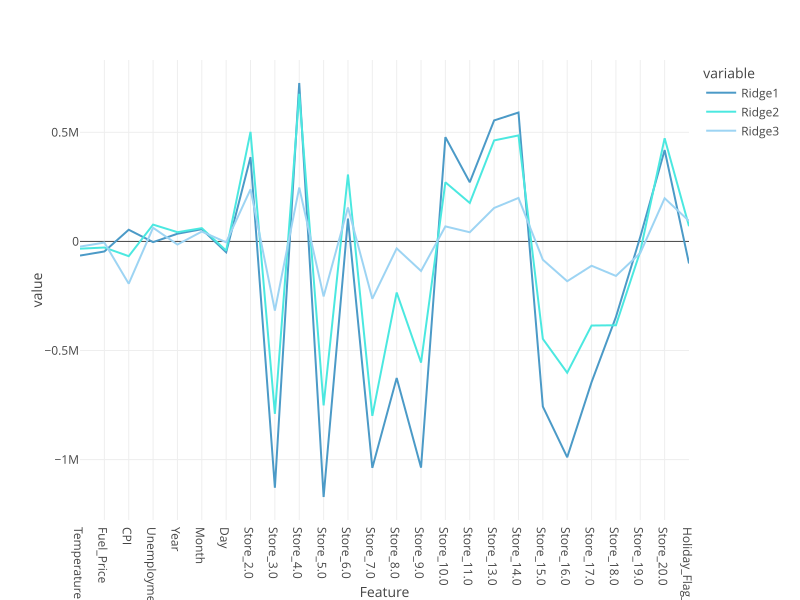

In [133]:
fig = px.line(coefficients_ridge, x = 'Feature', y = ['Ridge1', 'Ridge2', 'Ridge3'], height=600, width=800)
fig.show()

In [134]:
# Régularisation L1 LASSO avec 3 essais de paramètres pour éviter surapprentissage
lasso1 = Lasso(alpha = 1)
print(lasso1)
lasso1.fit(x_train, y_train)
# Print R^2 scores
print("R2 score sur set d'entrainement : ", lasso1.score(x_train, y_train))
print("R2 score sur set de test : ", lasso1.score(x_test, y_test))


Lasso(alpha=1)
R2 score sur set d'entrainement :  0.9746557331482395
R2 score sur set de test :  0.9514977201759273


In [135]:
lasso2 = Lasso(alpha = 30)
print(lasso2)
lasso2.fit(x_train, y_train)
# Print R^2 scores
print("R2 score sur set d'entrainement : ", lasso2.score(x_train, y_train))
print("R2 score sur set de test : ", lasso2.score(x_test, y_test))


Lasso(alpha=30)
R2 score sur set d'entrainement :  0.9746532918817901
R2 score sur set de test :  0.9520517796593388


In [136]:
lasso3 = Lasso(alpha = 100)
print(lasso3)
lasso3.fit(x_train, y_train)
# Print R^2 scores
print("R2 score sur set d'entrainement : ", lasso3.score(x_train, y_train))
print("R2 score sur set de test : ", lasso3.score(x_test, y_test))


Lasso(alpha=100)
R2 score sur set d'entrainement :  0.9746317574870502
R2 score sur set de test :  0.9533389637251082


In [137]:
data_dict = {
    'Feature' : preprocessor.get_feature_names_out().tolist(),
    'Lasso1' : lasso1.coef_,
    'Lasso2' : lasso2.coef_,
    'Lasso3' : lasso3.coef_
}

In [138]:
coefficients_lasso = pd.DataFrame(data = data_dict)
coefficients_lasso["Feature"] = coefficients_lasso["Feature"].str.replace(r"^(num__|cat__)", "", regex=True)
coefficients_lasso.head()

,Feature,Lasso1,Lasso2,Lasso3
0,Temperature,-74595.526299,-74139.453366,-73080.635264
1,Fuel_Price,-48668.680491,-48248.553191,-47212.267605
2,CPI,53059.812529,53251.955673,53821.126768
3,Unemployment,-52147.055155,-50978.015327,-48890.726533
4,Year,20321.264963,20349.215901,20048.771068


In [139]:
# création d'un tableau de synthèse
data_dict = {
    'Feature': column_names,
    'Lasso1': lasso1.coef_,
    'Lasso2': lasso2.coef_,
    'Lasso3': lasso3.coef_
            }

coefficients_lasso = pd.DataFrame(data = data_dict)
coefficients_lasso["Feature"] = coefficients_lasso["Feature"].str.replace(r"^(num__|cat__)", "", regex=True)
coefficients_lasso.head()


,Feature,Lasso1,Lasso2,Lasso3
0,Temperature,-74595.526299,-74139.453366,-73080.635264
1,Fuel_Price,-48668.680491,-48248.553191,-47212.267605
2,CPI,53059.812529,53251.955673,53821.126768
3,Unemployment,-52147.055155,-50978.015327,-48890.726533
4,Year,20321.264963,20349.215901,20048.771068


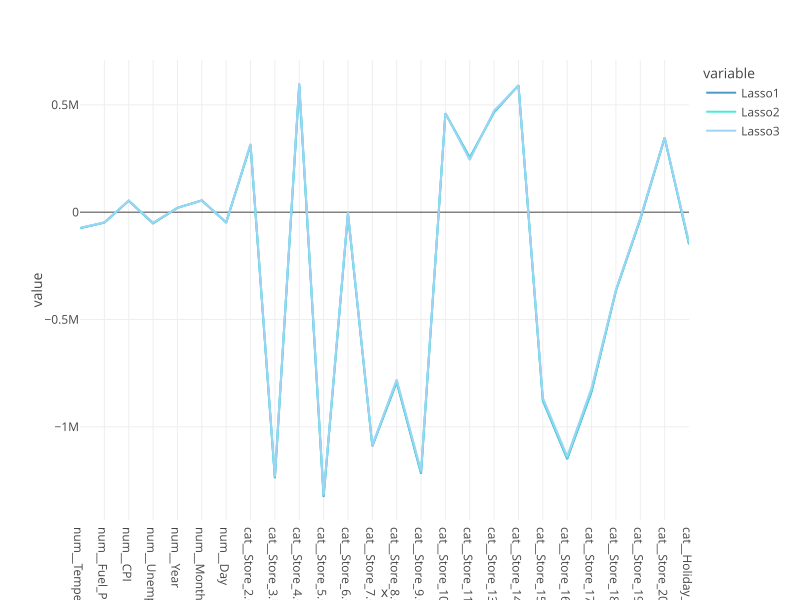

In [140]:
fig = px.line(coefficients_lasso, x = column_names, y = ['Lasso1', 'Lasso2', 'Lasso3'], height = 600, width = 800)
fig.show()

In [141]:
# On teste les meilleurs paramètres sur RIDGE
print("Grid search...")
regressor = Ridge()
# Grille de valeurs à tester
params = {
    'alpha': [0.0001, 0.001, 0.0012, 0.1, 0.5, 1, 5, 10]
}
best_ridge = GridSearchCV(regressor, param_grid = params, cv = 10, verbose = 1) # cv
best_ridge.fit(x_train, y_train)
print("...Fait.")
print("Meilleur hyperparamètre sur RIDGE: ", best_ridge.best_params_)
print("Meilleur R2 score sur RIDGE : ", best_ridge.best_score_)


Grid search...
Fitting 10 folds for each of 8 candidates, totalling 80 fits
...Fait.
Meilleur hyperparamètre sur RIDGE:  {'alpha': 0.0012}
Meilleur R2 score sur RIDGE :  0.8959972834771642


In [142]:
# On teste les meilleurs paramètres sur LASSO
print("Grid search...")
regressor = Lasso(max_iter=int(1e6))
# Grille de valeurs à tester
params = {
    'alpha': [0.0001, 0.001, 0.1, 1, 2, 3, 5, 10, 20, 28, 30, 100]
}
best_lasso = GridSearchCV(regressor, param_grid = params, cv = 10, verbose = 1)
best_lasso.fit(x_train, y_train)
print("...Fait.")
print("Meilleur hyperparamètre sur LASSO: ", best_lasso.best_params_)
print("Meilleur R2 score sur LASSO : ", best_lasso.best_score_)


Grid search...
Fitting 10 folds for each of 12 candidates, totalling 120 fits
...Fait.
Meilleur hyperparamètre sur LASSO:  {'alpha': 100}
Meilleur R2 score sur LASSO :  0.8963943244199161


In [143]:
# Comparaison des résultats sur RIDGE et LASSO
print("RIDGE / R2 score sur set d'entrainement : ", best_ridge.score(x_train, y_train))
print("RIDGE / R2 score sur set de test : ", best_ridge.score(x_test, y_test))
print()
print("LASSO / R2 score sur set d'entrainement : ", best_lasso.score(x_train, y_train))
print("LASSO / R2 score sur set de test : ", best_lasso.score(x_test, y_test))


RIDGE / R2 score sur set d'entrainement :  0.9746551962004718
RIDGE / R2 score sur set de test :  0.9516403466495166

LASSO / R2 score sur set d'entrainement :  0.9746317574870502
LASSO / R2 score sur set de test :  0.9533389637251082


In [144]:
data_dict = {
    'Feature': preprocessor.get_feature_names_out().tolist(),
    'Best_Ridge': best_ridge.best_estimator_.coef_,
    'Best_Lasso': best_lasso.best_estimator_.coef_
            }

coefficients = pd.DataFrame(data = data_dict)
coefficients["Feature"] = coefficients['Feature'].str.replace(r"^(num__|cat__)", "", regex=True)
coefficients.head()


,Feature,Best_Ridge,Best_Lasso
0,Temperature,-74445.954746,-73080.635264
1,Fuel_Price,-48666.783243,-47212.267605
2,CPI,53591.936676,53821.126768
3,Unemployment,-51370.785122,-48890.726533
4,Year,20564.849423,20048.771068


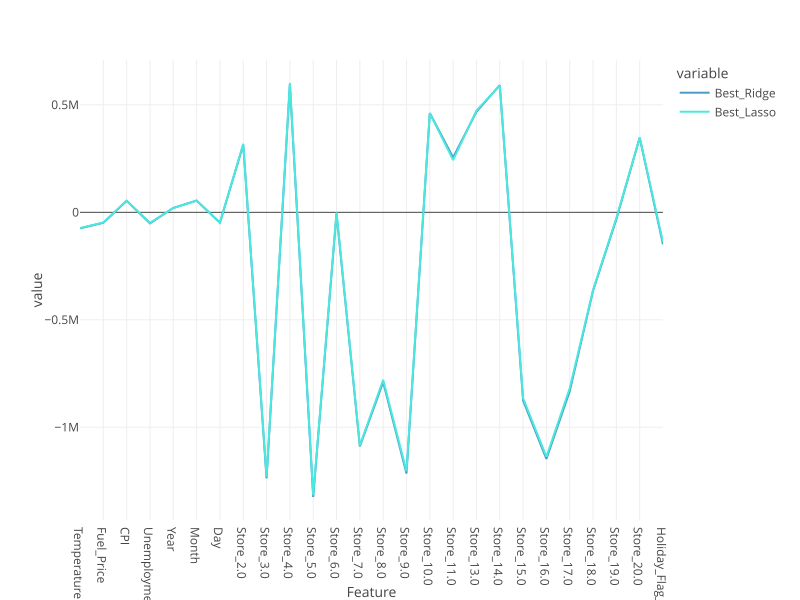

In [145]:
color=[ '#e74c3c','#3498db' ]
color_discrete_sequence = color
#color = y
fig = px.line(coefficients, x = 'Feature', y = ['Best_Ridge', 'Best_Lasso'], height = 600, width = 800)
fig.show()


In [146]:
# Vérification que l'overfitting a été corrigé
scores = cross_val_score(best_ridge,x_train, y_train, cv=5)
avg = scores.mean()
std = scores.std()
print('Précision validée par croisement : {}\nécart-type : {}'.format(avg, std))
print("R2 score sur set de test final : ", best_ridge.score(x_test, y_test) + std, "à", best_ridge.score(x_test, y_test) - std)
print("et c'est inférieur au R2 score sur set d'entrainement :", best_ridge.score(x_train, y_train))

Fitting 10 folds for each of 8 candidates, totalling 80 fits
Fitting 10 folds for each of 8 candidates, totalling 80 fits
Fitting 10 folds for each of 8 candidates, totalling 80 fits
Fitting 10 folds for each of 8 candidates, totalling 80 fits
Fitting 10 folds for each of 8 candidates, totalling 80 fits
Précision validée par croisement : 0.8907406486749911
écart-type : 0.039977890474262784
R2 score sur set de test final :  0.9916182371237794 à 0.9116624561752538
et c'est inférieur au R2 score sur set d'entrainement : 0.9746551962004718


In [147]:
# Validation croisée avec cross_val_score pour évaluer la performance du modèle de machine-learning en divisant
# le jeu de données en plusieurs plis
scores = cross_val_score(best_lasso,x_train, y_train, cv=5)
avg = scores.mean()
std = scores.std()
print('Précision validée par croisement : {}\nstandard deviation : {}'.format(avg, std))
print("R2 score sur set de test final : ", best_lasso.score(x_test, y_test) + std, "or ", best_lasso.score(x_test, y_test) - std)
print("par rapport au R2 score sur set d'entrainement :", best_lasso.score(x_train, y_train))

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Précision validée par croisement : 0.8867419636558422
standard deviation : 0.05196673333224228
R2 score sur set de test final :  1.0053056970573504 or  0.9013722303928658
par rapport au R2 score sur set d'entrainement : 0.9746317574870502


In [148]:
print(f"Meilleur score RIDGE sur set d'entrainement :", best_ridge.score(x_train, y_train))
print(f"Meilleur score LASSO sur set d'entrainement :", best_lasso.score(x_train, y_train))
print()
print(f"Meilleur score RIDGE sur set de test :", best_ridge.score(x_test, y_test))
print(f"Meilleur score LASSO sur set de test :", best_lasso.score(x_test, y_test))

Meilleur score RIDGE sur set d'entrainement : 0.9746551962004718
Meilleur score LASSO sur set d'entrainement : 0.9746317574870502

Meilleur score RIDGE sur set de test : 0.9516403466495166
Meilleur score LASSO sur set de test : 0.9533389637251082


In [149]:
# Le niveau des scores moyens sur le set de test est légèrement inférieur à celui des scores sur set d'entrainement.
# C'est cohérent, mais leur importante proximité nous conforte dans l'idée qu'il n'y a pas de réel surapprentissage.

In [150]:
# Il semble que ce soit le RIDGE avec alpha = 0.0012 qui soit le meilleur pour corriger le petit surapprentissage du début.